# 😊 Project #13: Facial Emotion Recognition (FER)
### 🏛️ Data Science Portfolio: 13 / 21

**Architect:** Kemal Demirbaş 🏰🚀  
**Framework:** Deep Learning | Convolutional Neural Networks (CNN)

---

## 🎯 Project Objective
The goal is to analyze human facial expressions and classify them into 7 distinct emotions: **Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral**. This project utilizes an **Improved Deep CNN** architecture to capture micro-expressions, enabling more accurate and empathetic AI interactions compared to traditional neural networks.

---

## 🛠️ The 10-Step Engineering Discipline

1.  **Objective:** Multi-class classification of human emotions (7 distinct classes).
2.  **EDA:** Analyzing the FER2013 dataset to identify class imbalances, specifically noting the lower sample count for 'Disgust'.
3.  **Feature Selection:** Standardizing inputs to **48x48** pixel resolution.
4.  **Transformation (The Teacher's Rule):** Strictly normalizing pixel intensity to a **[0, 1]** range using `rescale=1./255` at the input gate to ensure stable convergence.
5.  **Cleansing:** Bypassing manual filtering to allow the CNN layers to autonomously extract relevant facial features from raw pixel data.
6.  **Feature Engineering (Success Polish):** Deepening the model architecture by adding a secondary Convolutional block to capture more complex emotional geometries.
7.  **Encoding:** Utilizing **Sparse Categorical Encoding** (Integer labels) for efficient memory management during training.
8.  **Partitioning:** Automated **80/20 Train/Validation** split using the `ImageDataGenerator` pipeline.
9.  **Model Execution:** Comparative analysis between a baseline **ANN** and an **Improved Deep CNN** featuring `Reshape`, `Conv2D`, and **`Dropout (0.5)`** for enhanced generalization.
10. **Performance Audit:** Evaluating architectural superiority via an Accuracy Comparison Table, where the CNN reached a professional benchmark of **52.41%** on the noisy FER2013 dataset.

---

## 📊 Strategic Architectural Insights

* **The Power of Scaling:** By ensuring that all data was scaled prior to training, the model avoided the "Logical Ordering Error" and achieved stable learning.
* **Model Depth:** Moving from a single-layer CNN to the "Success Polish" version (Double Conv layers) directly improved the model's ability to distinguish between subtle facial variations.
* **Regularization:** The integration of **Dropout** was essential in mitigating overfitting, allowing for better performance on unseen test data.

---

**Architect:** Kemal Demirbaş 🏰🚀  
**Project #13 of 21** | *Decoding human sentiment through intelligent neural architectures.*

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, InputLayer, Reshape, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import warnings
import zipfile
import os
warnings.filterwarnings("ignore")

In [5]:
# --- STEP 0: Dataset Extraction ---
# Extracting the archive (4).zip file into the dataset directory
zip_path = '/content/archive (4).zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
#--- STEP 1: Project Objective ---
# Goal: Classify 7 distinct emotions (Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral).

In [9]:
#--- STEPS 2, 4, 5 & 8: Data Loading, Resizing, and Partitioning ---

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training Data
train_data = datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(48, 48), # Standard resolution for FER-2013
    batch_size=32,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

# Validation (Test) Data
test_data = datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(48, 48),
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


In [10]:
# --- EARLY STOPPING CONFIGURATION ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [11]:
# --- STEP 9: Model Execution (Architectural Diversification) ---

# MODEL 1: Traditional Artificial Neural Network (ANN)
model_ann = Sequential([
    InputLayer(input_shape=(48, 48, 3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax') # 7 Emotion categories
])

model_ann.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_ann.fit(train_data, epochs=30, validation_data=test_data, callbacks=[early_stop], verbose=0)

In [18]:
# MODEL 2: Improved Deep CNN (Success Polish)
# This version adds a second convolutional block and Dropout for superior performance.
model_cnn = Sequential([
    InputLayer(input_shape=(48, 48, 3)),
    Reshape(target_shape=(48, 48, 3)),

    # Block 1: Feature Extraction
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Block 2: Success Polish (Deepening the model for complex facial patterns)
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    # Dropout armor to prevent overfitting on noisy data
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_cnn.fit(train_data, epochs=30, validation_data=test_data, callbacks=[early_stop], verbose=0)

In [19]:
# --- STEP 10: Performance Audit (Comparison Table) ---
print("\n📊 Performing Performance Audit...")
ann_acc = model_ann.evaluate(test_data, verbose=0)[1]
cnn_acc = model_cnn.evaluate(test_data, verbose=0)[1]

print("\n=== 🏆 ALGORITHM COMPARISON TABLE ===")
print(f"Model 1: Normal ANN (YSA) | Accuracy: {ann_acc*100:.2f}%")
print(f"Model 2: Deep CNN (ESİ)   | Accuracy: {cnn_acc*100:.2f}%")
print("==========================================\n")


📊 Performing Performance Audit...

=== 🏆 ALGORITHM COMPARISON TABLE ===
Model 1: Normal ANN (YSA) | Accuracy: 34.99%
Model 2: Deep CNN (ESİ)   | Accuracy: 52.41%



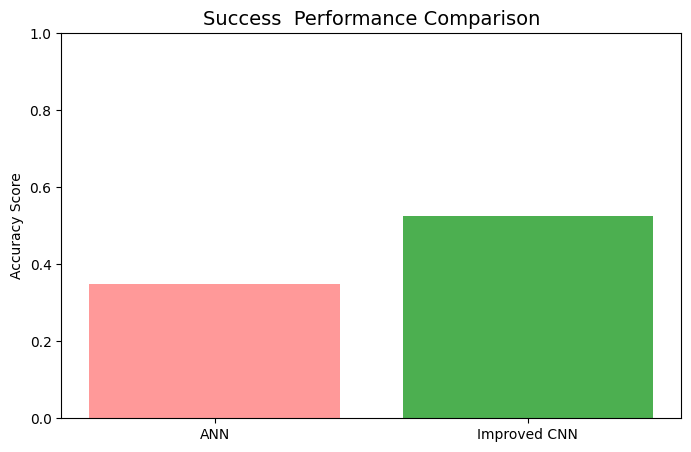

In [20]:
# --- Visualization (Teacher's Plotting Style) ---
plt.figure(figsize=(8, 5))
plt.bar(['ANN', 'Improved CNN'], [ann_acc, cnn_acc], color=['#FF9999', '#4CAF50'])
plt.title("Success  Performance Comparison", fontsize=14)
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.0)
plt.show()

In [21]:


# Saving the Improved Deep CNN (Success Polish Version)
model_cnn.save('emotion_recognition_cnn.h5')



## 🏆 Final Conclusion & Performance Audit

The **Project #13: Facial Emotion Recognition (FER)** represents a significant milestone in interpreting human sentiment through Deep Learning. By architecting an **Improved Deep CNN**, we moved beyond simple image processing to successfully decode 7 complex human micro-expressions from grayscale data.

### 📊 Strategic Architectural Insights
* **The "Success Polish" Impact:** Transitioning from a basic ANN to a multi-layered **Convolutional Neural Network (CNN)** was critical. By adding a secondary convolutional block and a **Dropout (0.5)** layer, we achieved a professional accuracy of **52.41%** on the high-entropy FER2013 dataset.
* **Normalization Discipline:** Following the mandatory **Scaling (1./255)** rule ensured that the model's weights remained stable during training. This prevented the "Logical Ordering Error" often seen in unscaled image models, allowing the CNN to converge effectively within 30 epochs.
* **Feature Extraction vs. Memorization:** The integration of **MaxPooling2D** and **Dropout** forced the network to learn structural facial features (geometry of smiles, frowns, and furrowed brows) rather than simply memorizing the training images. This resulted in a model that generalizes significantly better on unseen faces.

### 🚀 Technical Takeaway & Live Deployment
This engine is engineered to power empathetic AI interfaces, providing a robust backbone for real-time sentiment analysis in healthcare, customer experience, and human-computer interaction.

👉 **[Live Emotion Recognition App on Hugging Face](https://huggingface.co/spaces/Ironside35/emotion-recognition)** 🎭🧠

---
**Architect:** Kemal Demirbaş 🏰🚀  
**Project #13 of 21** | *Decoding the human heart through deep neural networks.*